In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU
from tensorflow.keras.optimizers import RMSprop
import numpy as np
from sklearn.model_selection import TimeSeriesSplit


In [2]:
df = pd.read_csv('/home/purushottam/MACHINE LEARNING/TIME SERIES/DATASETS/sales data.csv')

In [3]:
df['Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Date')
df = df.set_index('Date')

/tmp/ipykernel_49535/3983258655.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Order Date'])


In [4]:
del df['Order Date'] 
del df['Ship Date']
del df['Customer ID']
del df['Customer Name']
del df['Order ID']
del df['Ship Mode']
del df['Product ID']
del df['Product Name']
del df['City']
del df['Region']
del df['State']

In [5]:
df = pd.get_dummies(df, columns= ['Segment', 'Country','Category', 'Sub-Category'])

In [6]:
q1 = df['Sales'].quantile(0.25)
q3  = df['Sales'].quantile(0.75)

iqr = q3 - q1 

upper = q3 + 1.5 * iqr
lower = q1 - 1.5 * iqr

df = df[(df['Sales'] <= upper ) & (df['Sales'] >= 200)]

In [7]:
def time(df):
    df['Month'] = df.index.month
    df['Year'] = df.index.year 
    df['Dayofweek'] = df.index.dayofweek
    df['Dayofyear'] = df.index.dayofyear
    df['Quarter'] = df.index.quarter
    return df

def features(df):
    df['Lag 1'] = df['Sales'].shift(1)
    df['Lag 7'] = df['Sales'].shift(7)
    df['Lag 30'] = df['Sales'].shift(30)
    df['MA 7'] = df['Sales'].shift(1).rolling(7).mean()
    df['MA 30'] = df['Sales'].shift(1).rolling(30).mean()
    df['STD 7'] = df['Sales'].shift(1).rolling(7).std()
    df['STD 30'] = df['Sales'].shift(1).rolling(30).std()
    return df

def residuals_features(df):
    df['Lag 1'] = df['Residuals'].shift(1)
    df['Lag 7'] = df['Residuals'].shift(7)
    df['Lag 30'] = df['Residuals'].shift(30)
    df['MA 7'] = df['Residuals'].shift(1).rolling(7).mean()
    df['MA 30'] = df['Residuals'].shift(1).rolling(30).mean()
    df['STD 7'] = df['Residuals'].shift(1).rolling(7).std()
    df['STD 30'] = df['Residuals'].shift(1).rolling(30).std()
    return df

In [8]:
train = df[(df.index >= '2015-01-02') & (df.index < '2017-06-02')]
val = df[(df.index >= '2017-06-02') & (df.index < '2018-03-01')]
test = df[(df.index >= '2018-03-01') & (df.index < '2018-12-30')]


In [9]:
train = time(train)
train = features(train)

val = time(val)
val = features(val)

test = time(test)
test = features(test)

train.dropna(inplace= True )
val.dropna(inplace = True)
test.dropna(inplace = True)


In [10]:
train = train.reset_index('Date')
test = test.reset_index('Date')
val = val.reset_index('Date')

del train['Date']
del test['Date']
del val['Date']

In [11]:
x_train = train.drop('Sales', axis = 1)
y_train = train['Sales'] 

x_val = val.drop('Sales', axis = 1)
y_val = val['Sales']

x_test = test.drop('Sales', axis = 1)
y_test = test['Sales']

In [12]:
def validate(x_train, y_train):
    tf_pred = np.full(len(x_train), np.nan)
    
    tsv = TimeSeriesSplit(n_splits= 5)

    for fold, (train_idx, pred_idx) in enumerate(tsv.split(x_train)):

        x_tr = x_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]

        x_pred = x_train.iloc[pred_idx]

        xgb = XGBRegressor(n_estimators = 1500, learning_rate = 0.005,
                             max_depth = 5)

        xgb.fit(x_tr, y_tr)

        tf_pred[pred_idx] = xgb.predict(x_pred)

    return tf_pred

In [13]:
train_pred_wk = validate(x_train, y_train)

In [14]:
xgb = XGBRegressor(n_estimators = 1500, learning_rate = 0.005, max_depth = 5)
xgb.fit(x_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [15]:
pred_train = xgb.predict(x_train)
pred_val = xgb.predict(x_val)
pred_test = xgb.predict(x_test)


In [16]:
mae_train = mean_absolute_error(y_train, pred_train)
print ("TRAIN ERROR:%.2f"%mae_train)
mae_val = mean_absolute_error(y_val, pred_val)
print ("VAL ERROR:%.2f"%mae_val)
mae_test = mean_absolute_error(y_test, pred_test)
print ("TEST ERROR:%.2f"%mae_test)

TRAIN ERROR:56.44
VAL ERROR:72.81
TEST ERROR:71.49


In [17]:
train['Prediction'] = train_pred_wk
train['Residuals'] = train['Sales'] - train['Prediction']

val['Prediction'] = pred_val
val['Residuals'] = val['Sales'] - val['Prediction']

test['Prediction'] = pred_test
test['Residuals'] = test['Sales'] - test['Prediction']

In [18]:
train = residuals_features(train)
val = residuals_features(val)
test = residuals_features(test)

In [19]:
train.dropna(inplace= True)
val.dropna(inplace= True)
test.dropna(inplace=True)

In [20]:
x_train_l = train.drop(['Sales', 'Residuals'], axis = 1)
y_train_l = train['Residuals']

x_val_l = val.drop(['Sales', 'Residuals'], axis  = 1)
y_val_l = val['Residuals']

x_test_l = test.drop(['Sales', 'Residuals'], axis = 1)
y_test_l = test['Residuals']

In [21]:
x_val_l = x_val_l.reindex(columns= x_train_l.columns, fill_value= 0)
x_test_l = x_test_l.reindex(columns= x_train_l.columns, fill_value= 0)

In [46]:
zero_std_cols = x_train_l.columns[x_train_l.std() == 0]

x_train_l = x_train_l.drop(columns= zero_std_cols)
x_val_l = x_val_l.drop(columns= zero_std_cols)
x_test_l = x_test_l.drop(columns= zero_std_cols)

In [47]:
x_mean = x_train_l.mean()
x_std = x_train_l.std()
x_std = x_std.replace(0, 1)


x_train_sc = (x_train_l - x_mean) / x_std
x_val_sc = (x_val_l - x_mean) / x_std
x_test_sc = (x_test_l - x_mean) / x_std

y_mean = y_train_l.mean()
y_std = y_train_l.std()

y_train_sc = (y_train_l - y_mean) / y_std
y_val_sc = (y_val_l - y_mean) / y_std
y_test_sc = (y_test_l - y_mean) / y_std

In [48]:
def window(x, y, window):
    x = np.array(x)
    y = np.array(y)
    
    x_seq = []
    y_seq = []

    for i in range(window, len(x)):
        x_seq.append(x[i-window:i])
        y_seq.append(y[i])

    return np.array(x_seq), np.array(y_seq)

In [49]:
x_train_sc, y_train_sc = window(x_train_sc, y_train_sc, 30)
x_val_sc, y_val_sc = window(x_val_sc, y_val_sc, 30)
x_test_sc, y_test_sc = window(x_test_sc, y_test_sc, 30)

In [50]:
model = Sequential()

model.add(GRU(256, input_shape = (30, 43)))
model.add(Dense(128))
model.add(Dense(64))
model.add(Dense(32))
model.add(Dense(1))

model.compile(optimizer= RMSprop(), loss = 'mean_absolute_error')

In [51]:
model.fit(x_train_sc, y_train_sc, epochs= 64, batch_size= 32)

Epoch 1/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.7005
Epoch 2/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.6793
Epoch 3/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.6766
Epoch 4/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.6744
Epoch 5/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.6701
Epoch 6/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.6691
Epoch 7/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.6675
Epoch 8/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.6657
Epoch 9/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.6637
Epoch 10/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.6591
Epoch 11/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.6516
Epoch 12/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.6440
Epoch 13/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.6312
Epoch 14/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.6185
Epoch 15/64
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s

In [52]:
predict_train = model.predict(x_train_sc)
predict_val = model.predict(x_val_sc)
predict_test = model.predict(x_test_sc)

120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [53]:
predict_train = np.reshape(predict_train,(3830, ))
predict_val = np.reshape(predict_val, (1875, ))
predict_test = np.reshape(predict_test, (2598, ))

In [54]:
predict_train = predict_train * y_std + y_mean
predict_val = predict_val * y_std + y_mean
predict_test = predict_test * y_std + y_mean

In [55]:
y_train_sc = y_train_sc * y_std + y_mean
y_val_sc = y_val_sc * y_std + y_mean
y_test_sc = y_test_sc * y_std + y_mean

In [56]:
xgb_pred_train = train['Prediction'].iloc[30:]
xgb_pred_val = val['Prediction'].iloc[30:]
xgb_pred_test = test["Prediction"].iloc[30:]


In [57]:
final_pred_train = xgb_pred_train + predict_train
final_pred_val = xgb_pred_val + predict_val
final_pred_test = xgb_pred_test + predict_test

In [58]:
y_train_final = train['Sales'].iloc[30:].values
y_val_final = val['Sales'].iloc[30:].values
y_test_final = test['Sales'].iloc[30:].values

In [59]:
mae_final_train = mean_absolute_error(y_train_final, final_pred_train)
print ("TRAIN FINAL ERROR:%.2f"%mae_final_train)

mae_final_val = mean_absolute_error(y_val_final, final_pred_val)
print ("VAL FINAL ERROR:%.2f"%mae_final_val)

mae_final_test = mean_absolute_error(y_test_final, final_pred_test)
print ("TEST FINAL ERROR:%.2f"%mae_final_test)

TRAIN FINAL ERROR:21.33
VAL FINAL ERROR:89.85
TEST FINAL ERROR:92.90


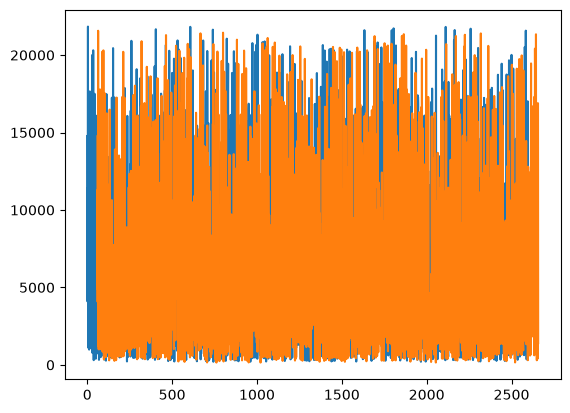

In [60]:
import matplotlib.pyplot as plt

plt.plot(y_test_final)
plt.plot(final_pred_test)

In [62]:
df['Sales'].mean()

np.float64(6496.116756811791)